<a href="https://www.kaggle.com/code/nithinreddy600/q9-market-research-component?scriptVersionId=320037417" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Q9. How does the Global Currency Tracker show the role of USD in international payments?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA_PATH = Path("/kaggle/input/datasets/nithinreddy600/dbs-research")
OUTPUT_PATH = Path("/kaggle/working")
OUTPUT_PATH.mkdir(exist_ok=True)

swift = pd.read_csv(DATA_PATH / "swift_currency_tracker_all_reports.csv")
swift.columns = swift.columns.astype(str).str.strip()

print("SWIFT dataset loaded:", swift.shape)
print("Columns:")
for i, c in enumerate(swift.columns):
    print(i, repr(c))

display(swift.head())


SWIFT dataset loaded: (288, 9)
Columns:
0 'report_month'
1 'data_month'
2 'source_report_name'
3 'metric'
4 'category'
5 'currency_or_economy'
6 'value'
7 'unit'
8 'notes'


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,Rank 5


In [2]:
def find_col(df, keywords):
    for key in keywords:
        matches = [c for c in df.columns if key.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

def find_value_col(df):
    for c in df.columns:
        if c.lower().strip() == "value":
            return c
    scores = {}
    for c in df.columns:
        temp = df[c].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        scores[c] = pd.to_numeric(temp, errors="coerce").notna().sum()
    return max(scores, key=scores.get)

value_col = find_value_col(swift)
currency_col = find_col(swift, ["currency/economy", "currency", "economy"])
metric_col = find_col(swift, ["metric"])
category_col = find_col(swift, ["category"])
rank_col = find_col(swift, ["rank"])
month_col = find_col(swift, ["data month", "report month", "month", "date"])

swift[value_col] = (
    swift[value_col].astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
)
swift[value_col] = pd.to_numeric(swift[value_col], errors="coerce")

print("Using value column:", value_col)
print("Using currency/economy column:", currency_col)
print("Using metric column:", metric_col)
print("Using category column:", category_col)
print("Using rank column:", rank_col)
print("Using month column:", month_col)

df = swift.copy()

if month_col:
    parsed_month = pd.to_datetime(df[month_col], errors="coerce")
    if parsed_month.notna().sum() > 0:
        df["_parsed_month"] = parsed_month
        latest_month = df["_parsed_month"].max()
        df = df[df["_parsed_month"] == latest_month]
        print("Latest month used:", latest_month)
    else:
        print("Month column found, but dates could not be parsed. Using all rows.")
else:
    print("No month column found. Using all rows.")

work = df.copy()
if metric_col:
    payment_rows = work[work[metric_col].astype(str).str.contains("payment|payments", case=False, na=False)]
    if len(payment_rows) > 0:
        work = payment_rows

ranking = work[[currency_col, value_col]].dropna()
ranking = ranking.groupby(currency_col, as_index=False)[value_col].max().sort_values(value_col, ascending=False)

top10 = ranking.head(10)
display(top10)
top10.to_csv(OUTPUT_PATH / "Q9_top10_global_payment_currencies.csv", index=False)

usd_rows = ranking[ranking[currency_col].astype(str).str.contains("USD|US Dollar|Dollar", case=False, na=False)]
display(usd_rows.head(10))
usd_rows.to_csv(OUTPUT_PATH / "Q9_USD_value_or_rank.csv", index=False)


Using value column: value
Using currency/economy column: currency_or_economy
Using metric column: metric
Using category column: category
Using rank column: None
Using month column: report_month
Latest month used: 2026-04-01 00:00:00


/tmp/ipykernel_16/3325092184.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_month = pd.to_datetime(df[month_col], errors="coerce")


,currency_or_economy,value
20,USD,58.50
6,EUR,21.30
7,GBP,6.54
10,JPY,5.32
3,CNY,3.10
1,CAD,3.03
2,CHF,2.15
0,AUD,1.93
8,HKD,1.76
17,SGD,1.23


,currency_or_economy,value
20,USD,58.5


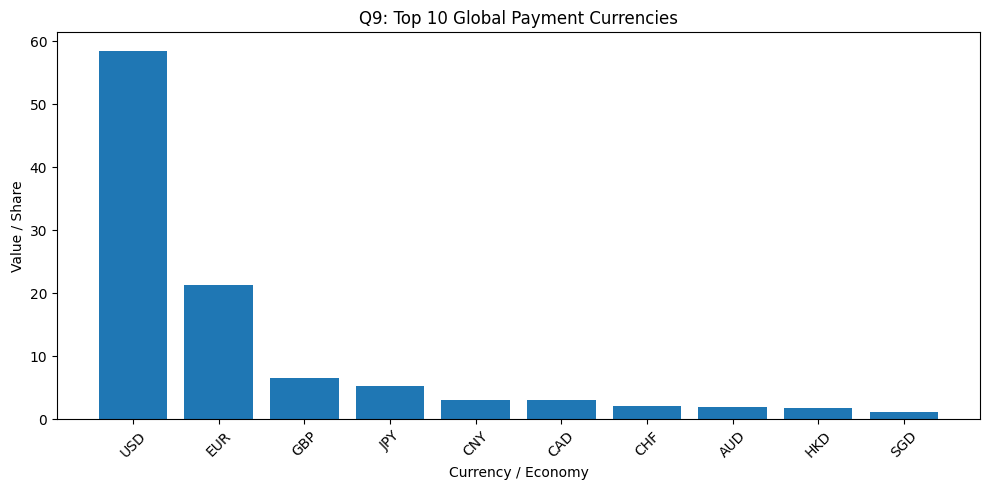

In [3]:
plt.figure(figsize=(10,5))
plt.bar(top10[currency_col].astype(str), top10[value_col])
plt.title("Q9: Top 10 Global Payment Currencies")
plt.xlabel("Currency / Economy")
plt.ylabel("Value / Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "Q9_top10_global_payment_currencies.png", dpi=300)
plt.show()


## Answer

The Global Currency Tracker shows the role of USD by ranking currencies according to their international payment value/share. In the ranking table generated above, USD can be compared with other major currencies, it shows that the US Dollar remains a key currency for cross-border payments, trade settlement, and international banking.

Use the generated file `Q9_USD_value_or_rank.csv` to mention the exact USD value/ranking in your report.